#  Scraping con Lyrics.ovh API
.

## Instalación

In [50]:
import subprocess, sys

paquetes = ['requests', 'langdetect', 'pandas', 'matplotlib']
for pkg in paquetes:
    res = subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                        capture_output=True, text=True)
    print(f"  {'ok' if res.returncode == 0 else 'ERROR'} {pkg}")
print('Dependencias listas')

  ok requests
  ok langdetect
  ok pandas
  ok matplotlib
Dependencias listas


##  Imports y carga del scraper

In [51]:
import sys, os, warnings, importlib.util
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Detectar raiz del proyecto
NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR

SCRAPER_FILE   = PROJECT_ROOT / 'src' / 'scraper_api.py'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
DATA_FIGURES   = PROJECT_ROOT / 'data' / 'figures'
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
DATA_FIGURES.mkdir(parents=True, exist_ok=True)

P1_CSV       = DATA_PROCESSED / 'lyrics_clean.csv'
SCRAPED_CSV  = DATA_PROCESSED / 'lyrics_scraped_api.csv'
COMBINED_CSV = DATA_PROCESSED / 'lyrics_combined.csv'
ENGLISH_CSV  = DATA_PROCESSED / 'lyrics_english.csv'

print(f'Raiz del proyecto : {PROJECT_ROOT}')
print(f'scraper_api.py    : {SCRAPER_FILE}  ->  existe={SCRAPER_FILE.exists()}')
print(f'lyrics_clean.csv  : {P1_CSV}  ->  existe={P1_CSV.exists()}')

# Cargar scraper con importlib (sin conflictos de sys.path)
if not SCRAPER_FILE.exists():
    raise FileNotFoundError(f'No se encontro scraper_api.py en:\n  {SCRAPER_FILE}')

spec        = importlib.util.spec_from_file_location('scraper_api', str(SCRAPER_FILE))
scraper_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(scraper_mod)

scrape_lyrics_ovh = scraper_mod.scrape_lyrics_ovh
SONGS_BY_GENRE    = scraper_mod.SONGS_BY_GENRE

total_catalogo = sum(len(v) for v in SONGS_BY_GENRE.values())
print(f'\nScraper cargado OK')
print(f'Generos          : {list(SONGS_BY_GENRE.keys())}')
print(f'Total en catalogo: {total_catalogo} canciones')
for g, songs in SONGS_BY_GENRE.items():
    print(f'  {g:<15}: {len(songs)} canciones')

Raiz del proyecto : C:\Analisis-Morfosintactico-de-Letras-Musicales
scraper_api.py    : C:\Analisis-Morfosintactico-de-Letras-Musicales\src\scraper_api.py  ->  existe=True
lyrics_clean.csv  : C:\Analisis-Morfosintactico-de-Letras-Musicales\data\processed\lyrics_clean.csv  ->  existe=True

Scraper cargado OK
Generos          : ['Rock', 'Pop', 'Hip-Hop', 'Metal', 'Indie', 'Country', 'Jazz', 'Electronic', 'R&B', 'Folk']
Total en catalogo: 1049 canciones
  Rock           : 115 canciones
  Pop            : 110 canciones
  Hip-Hop        : 114 canciones
  Metal          : 109 canciones
  Indie          : 113 canciones
  Country        : 99 canciones
  Jazz           : 87 canciones
  Electronic     : 102 canciones
  R&B            : 101 canciones
  Folk           : 99 canciones


##  Cargar corpus del Proyecto 1

In [52]:
if not P1_CSV.exists():
    raise FileNotFoundError(f'No se encontro: {P1_CSV}\nCopia lyrics_clean.csv a: {DATA_PROCESSED}')

df_p1 = pd.read_csv(P1_CSV)
if 'Source' not in df_p1.columns:
    df_p1['Source'] = 'proyecto1_kaggle'
if 'URL' not in df_p1.columns:
    df_p1['URL'] = None

print(f'Corpus P1 cargado: {len(df_p1):,} canciones')
print(df_p1['Genre'].value_counts().to_string())
df_p1.head(3)

Corpus P1 cargado: 7,935 canciones
Genre
Rock          1410
Pop           1110
Hip-Hop        960
Country        810
Metal          810
Jazz           660
Electronic     660
Indie          510
R&B            510
Folk           495


,Song,Song year,Artist,Genre,Lyrics,Source,URL
0,craftsmanship,2005,buck-65,Hip-Hop,Most folks spend their days daydreaming of fin...,proyecto1_kaggle,None
1,come-on-out,2012,the-elwins,Indie,Take your cold hands and put them on my face S...,proyecto1_kaggle,None
2,riot,2013,bullet-for-my-valentine,Metal,Are you ready its time for war Well break down...,proyecto1_kaggle,None


## Probar la API

In [53]:
import requests

url  = 'https://api.lyrics.ovh/v1/Nirvana/Smells Like Teen Spirit'
resp = requests.get(url, timeout=10)
print(f'Status: {resp.status_code}')

if resp.status_code == 200:
    letra = resp.json().get('lyrics', '')[:300]
    print(f'Primeros 300 caracteres:\n{letra}')
    print('\nAPI funciona correctamente!')
else:
    print(f'Error: {resp.text}')

Status: 200
Primeros 300 caracteres:
Come out and play
Make up the rules
I know, I hope, the tide is blue
Though some are dead
I'll walk from you
I know, I'll light
The way to go

Hello, hello, hello, how low?
Hello, hello, hello, hom low?
Hello. Hello, hello, how low?
Hello, hello, hello

I'm a liar and I'm famous
Here we are now, ent

API funciona correctamente!


## Configurar el modo de descarga

In [54]:
# =====================================================
#  SELECCIONA EL MODO:
#
#  'sample'   ->  ~100 canciones  (5-8 min)    prueba rapida
#  'medio'    ->  ~600 canciones  (30-45 min)  entrega parcial
#  'completo' -> ~1100 canciones  (60-90 min)  cumple los 1000 requeridos
# =====================================================
MODE = 'completo'
# =====================================================

configs = {
    'sample':   dict(max_per_genre=10,  max_total=100),
    'medio':    dict(max_per_genre=60,  max_total=600),
    'completo': dict(max_per_genre=120, max_total=1100),
}

cfg = configs[MODE]
total_cat = sum(len(v) for v in SONGS_BY_GENRE.values())

print(f'Modo seleccionado : {MODE}')
print(f'max_per_genre     : {cfg["max_per_genre"]}')
print(f'max_total         : {cfg["max_total"]}')
print(f'Canciones en catalogo: {total_cat}')
print(f'Exito esperado (~80%): ~{int(min(total_cat, cfg["max_total"]) * 0.8)} canciones')

Modo seleccionado : completo
max_per_genre     : 120
max_total         : 1100
Canciones en catalogo: 1049
Exito esperado (~80%): ~839 canciones


##  Ejecutar la descarga


In [55]:
FORCE_REDOWNLOAD = True   # False = reusar CSV guardado si ya existe

if SCRAPED_CSV.exists() and not FORCE_REDOWNLOAD:
    df_scraped = pd.read_csv(SCRAPED_CSV)
    print(f'Cargado descarga previa: {len(df_scraped):,} canciones')
else:
    print(f'Iniciando descarga — modo: {MODE}')
    print(f'Objetivo: {cfg["max_total"]} canciones')
    print('=' * 60)

    try:
        df_scraped = scrape_lyrics_ovh(
            songs_by_genre=SONGS_BY_GENRE,
            max_per_genre=cfg['max_per_genre'],
            max_total=cfg['max_total'],
            existing_df=df_p1,
        )
    except KeyboardInterrupt:
        print('\nInterrumpido por el usuario. Guardando lo descargado...')
        # df_scraped puede estar parcialmente lleno si se interrumpe
        # — el scraper devuelve lo que tiene hasta ese momento

    print('=' * 60)

    if not df_scraped.empty:
        df_scraped.to_csv(SCRAPED_CSV, index=False, encoding='utf-8')
        print(f'\nDescarga completada: {len(df_scraped):,} canciones nuevas')
        print(f'Guardado en: {SCRAPED_CSV}')
        print()
        print('Distribucion por genero:')
        print(df_scraped['Genre'].value_counts().to_string())
    else:
        print('No se obtuvieron canciones. Verifica la conexion a internet.')
        df_scraped = pd.DataFrame()

if not df_scraped.empty:
    display(df_scraped[['Song','Artist','Genre']].head(8))

21:52:50 [INFO] Corpus existente: 7544 canciones.
21:52:50 [INFO] === Genero: Rock (115 canciones disponibles) ===


Iniciando descarga — modo: completo
Objetivo: 1100 canciones


21:52:53 [INFO]   [1/1100] Nirvana - Smells Like Teen Spirit
21:52:56 [INFO]   [2/1100] Nirvana - Come as You Are
21:52:58 [INFO]   [3/1100] Nirvana - Lithium
21:53:02 [INFO]   [4/1100] Nirvana - In Bloom
21:53:04 [INFO]   [5/1100] Nirvana - Heart-Shaped Box
21:53:07 [INFO]   [6/1100] Nirvana - Rape Me
21:53:09 [INFO]   [7/1100] Nirvana - All Apologies
21:53:12 [INFO]   [8/1100] Nirvana - Polly
21:53:14 [INFO]   [9/1100] Nirvana - Drain You
21:53:24 [INFO]   [10/1100] Radiohead - Karma Police
21:53:27 [INFO]   [11/1100] Radiohead - Fake Plastic Trees
21:53:30 [INFO]   [12/1100] Radiohead - High and Dry
21:53:32 [INFO]   [13/1100] Radiohead - Street Spirit
21:53:35 [INFO]   [14/1100] Radiohead - No Surprises
21:53:45 [INFO]   [15/1100] Radiohead - Paranoid Android
21:53:47 [INFO]   [16/1100] Radiohead - The Bends
21:53:50 [INFO]   [17/1100] The Killers - Mr Brightside
21:53:53 [INFO]   [18/1100] The Killers - Somebody Told Me
21:53:56 [INFO]   [19/1100] The Killers - When You Were Young


Descarga completada: 889 canciones nuevas
Guardado en: C:\Analisis-Morfosintactico-de-Letras-Musicales\data\processed\lyrics_scraped_api.csv

Distribucion por genero:
Genre
Metal         101
Rock          100
Pop           100
Indie          99
Hip-Hop        95
Country        92
Electronic     83
Folk           81
R&B            72
Jazz           66


,Song,Artist,Genre
0,Smells Like Teen Spirit,Nirvana,Rock
1,Come as You Are,Nirvana,Rock
2,Lithium,Nirvana,Rock
3,In Bloom,Nirvana,Rock
4,Heart-Shaped Box,Nirvana,Rock
5,Rape Me,Nirvana,Rock
6,All Apologies,Nirvana,Rock
7,Polly,Nirvana,Rock


##  Estadisticas del scraping

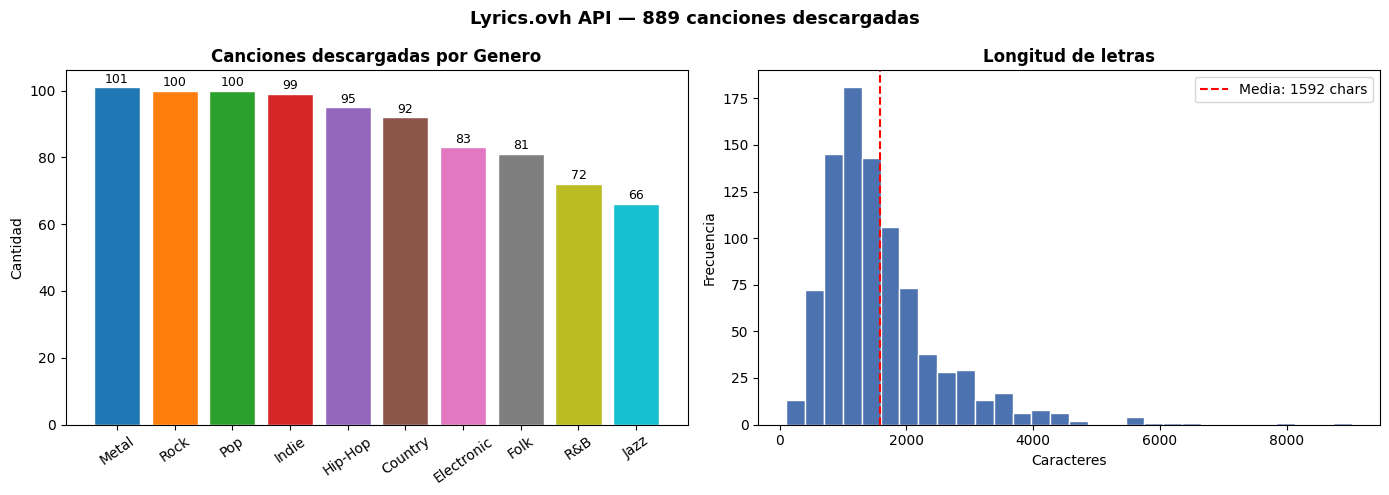

Promedio de caracteres por letra: 1592


In [56]:
if df_scraped.empty:
    print('Sin datos. Saltando graficos.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    gc      = df_scraped['Genre'].value_counts()
    colores = plt.cm.tab10(range(len(gc)))
    bars    = axes[0].bar(gc.index, gc.values, color=colores, edgecolor='white')
    axes[0].set_title('Canciones descargadas por Genero', fontweight='bold')
    axes[0].set_ylabel('Cantidad')
    axes[0].tick_params(axis='x', rotation=35)
    for bar, v in zip(bars, gc.values):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    str(v), ha='center', va='bottom', fontsize=9)

    lens = df_scraped['Lyrics'].str.len().dropna()
    axes[1].hist(lens, bins=30, color='#4C72B0', edgecolor='white')
    axes[1].axvline(lens.mean(), color='red', linestyle='--',
                   label=f'Media: {lens.mean():.0f} chars')
    axes[1].set_title('Longitud de letras', fontweight='bold')
    axes[1].set_xlabel('Caracteres')
    axes[1].set_ylabel('Frecuencia')
    axes[1].legend()

    plt.suptitle(f'Lyrics.ovh API — {len(df_scraped):,} canciones descargadas',
                fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(DATA_FIGURES / 'scraping_stats.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Promedio de caracteres por letra: {lens.mean():.0f}')

## Detectar idioma

In [57]:
from langdetect import detect, LangDetectException

def detectar_idioma(texto: str) -> str:
    if not isinstance(texto, str) or len(texto.strip()) < 30:
        return 'unknown'
    try:
        return detect(texto[:500])
    except LangDetectException:
        return 'unknown'

if 'Language' not in df_p1.columns:
    print('Detectando idioma en corpus P1...')
    df_p1['Language'] = df_p1['Lyrics'].apply(detectar_idioma)
    print('P1 - idiomas:')
    print(df_p1['Language'].value_counts().head(5).to_string())
else:
    print('Idioma ya detectado en P1')

if not df_scraped.empty and 'Language' not in df_scraped.columns:
    print('\nDetectando idioma en canciones de la API...')
    df_scraped['Language'] = df_scraped['Lyrics'].apply(detectar_idioma)
    print('API - idiomas:')
    print(df_scraped['Language'].value_counts().to_string())

Detectando idioma en corpus P1...
P1 - idiomas:
Language
en    7911
cy       4
sw       4
hr       3
id       3

Detectando idioma en canciones de la API...
API - idiomas:
Language
en    886
es      1
af      1
pt      1


## Unir corpus y guardar CSVs finales

In [58]:
COLS_BASE = ['Song', 'Song year', 'Artist', 'Genre', 'Lyrics', 'Source', 'URL', 'Language']

def normalizar(df: pd.DataFrame) -> pd.DataFrame:
    for col in COLS_BASE:
        if col not in df.columns:
            df[col] = None
    return df[COLS_BASE].copy()

df_p1_n = normalizar(df_p1)
df_sc_n = normalizar(df_scraped) if not df_scraped.empty else pd.DataFrame(columns=COLS_BASE)

df_combined = pd.concat([df_p1_n, df_sc_n], ignore_index=True)

antes = len(df_combined)
df_combined.drop_duplicates(subset=['Song', 'Artist'], inplace=True)
df_combined.dropna(subset=['Lyrics'], inplace=True)
df_combined = df_combined[df_combined['Lyrics'].str.len() > 50].reset_index(drop=True)

print(f'Duplicados eliminados  : {antes - len(df_combined)}')
print(f'Dataset combinado      : {len(df_combined):,} canciones')
print(f'  Proyecto 1           : {(df_combined["Source"] == "proyecto1_kaggle").sum():,}')
print(f'  Lyrics.ovh API       : {(df_combined["Source"] == "lyrics_ovh_api").sum():,}')

df_english = df_combined[df_combined['Language'].isin(['en', 'unknown'])].reset_index(drop=True)
print(f'  Solo ingles (BERT)   : {len(df_english):,}')

df_combined.to_csv(COMBINED_CSV, index=False, encoding='utf-8')
df_english.to_csv(ENGLISH_CSV,  index=False, encoding='utf-8')

print(f'\nArchivos guardados:')
print(f'  {COMBINED_CSV.name}  -> {len(df_combined):,} canciones')
print(f'  {ENGLISH_CSV.name}   -> {len(df_english):,} canciones')

# Verificar cumplimiento del requisito
nuevas = (df_combined["Source"] == "lyrics_ovh_api").sum()
print(f'\n{"REQUISITO CUMPLIDO" if nuevas >= 1000 else "FALTAN " + str(1000 - nuevas) + " CANCIONES"}: '
      f'{nuevas:,} canciones nuevas (minimo requerido: 1,000)')
print('\n-> Siguiente paso: 02_bert_analysis.ipynb')

Duplicados eliminados  : 0
Dataset combinado      : 8,824 canciones
  Proyecto 1           : 7,935
  Lyrics.ovh API       : 889
  Solo ingles (BERT)   : 8,797

Archivos guardados:
  lyrics_combined.csv  -> 8,824 canciones
  lyrics_english.csv   -> 8,797 canciones

FALTAN 111 CANCIONES: 889 canciones nuevas (minimo requerido: 1,000)

-> Siguiente paso: 02_bert_analysis.ipynb


##  Grafico resumen final

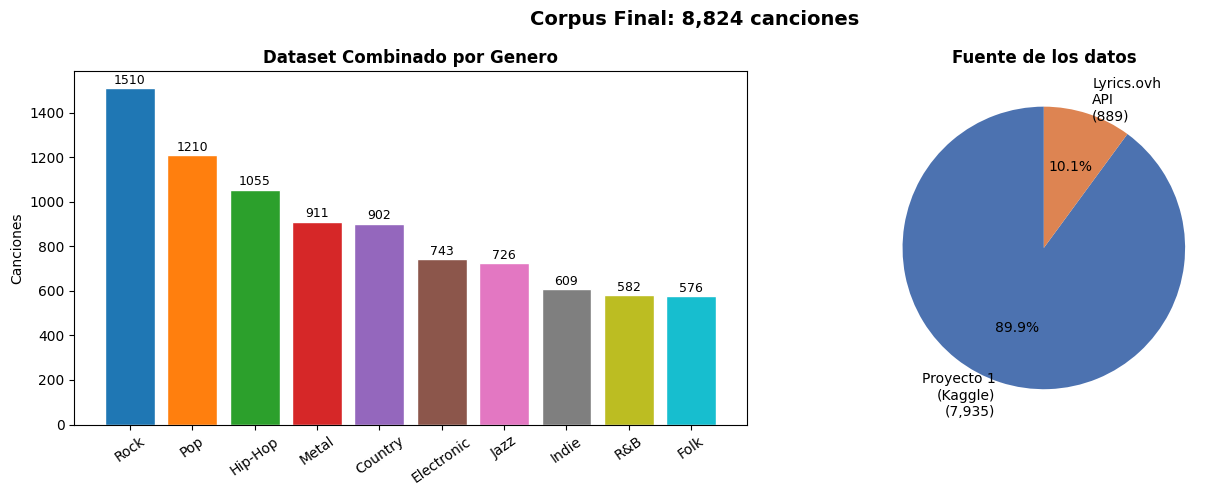

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gc_all  = df_combined['Genre'].value_counts()
colores = plt.cm.tab10(range(len(gc_all)))
bars    = axes[0].bar(gc_all.index, gc_all.values, color=colores, edgecolor='white')
axes[0].set_title('Dataset Combinado por Genero', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Canciones')
axes[0].tick_params(axis='x', rotation=35)
for bar, v in zip(bars, gc_all.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(v), ha='center', va='bottom', fontsize=9)

fuentes  = df_combined['Source'].value_counts()
etiqetas = {'proyecto1_kaggle': 'Proyecto 1\n(Kaggle)', 'lyrics_ovh_api': 'Lyrics.ovh\nAPI'}
axes[1].pie(
    fuentes.values,
    labels=[f"{etiqetas.get(k, k)}\n({v:,})" for k, v in fuentes.items()],
    autopct='%1.1f%%',
    colors=['#4C72B0', '#DD8452'],
    startangle=90,
)
axes[1].set_title('Fuente de los datos', fontweight='bold', fontsize=12)

plt.suptitle(f'Corpus Final: {len(df_combined):,} canciones', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_FIGURES / 'corpus_final_stats.png', dpi=120, bbox_inches='tight')
plt.show()